In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pylab as plt
from astropy.io import fits
from sklearn.cluster import KMeans
import sys
import os
import lightkurve as lk
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("star_functions.py"), '..')))
import star_functions as nana

/Users/natsuki/Projects/hogg_research/venv/lib/python3.9/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
fn = "/Users/natsuki/Projects/hogg_research/hoggnation/oscillator_catalog/good_parents_fit.fits"
with fits.open(fn) as hdu_list:
    print(hdu_list.info())
    data = hdu_list[1].data
    header = hdu_list[1].header
print(len(data), header)

Filename: /Users/natsuki/Projects/hogg_research/hoggnation/oscillator_catalog/good_parents_fit.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     21   1438R x 6C   [K, 12A, D, D, K, 65D]   
None
1438 XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  564 / length of dimension 1                          NAXIS2  =                 1438 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    6 / number of table fields                         TTYPE1  = 'parent_mode_id'                              

## Creating features vectpr for k means getting rid f nans

In [8]:
features = data["features"]
print(features.shape)
kics = data["star_id"]
print(kics.shape)

#create the time invariant feature vector for clustering (log(a0^2), log(a1^2 + b1^2), ...)
squared_feats = np.zeros((1438, 33))
for e,f in enumerate(features):
    j = 0
    for i in range(len(f) - 1):
        if i == 0:
            squared_feats[e][j] = f[i]**2
            j = j + 1
        if i%2 == 1:
            squared_feats[e][j] = f[i]**2 + f[i+1]**2
            j = j + 1

foo, k = squared_feats.shape
print(squared_feats.shape)
frequencies = np.outer(data["refined_frequency"], (1. + np.arange(k)))
informations = np.nansum(squared_feats * frequencies * (frequencies < 24.), axis=1)
print(informations)


refined_freqs = data["refined_frequency"]
good_mask = ~np.any(np.isnan(squared_feats), axis=1)
print("good mask", good_mask.shape)
print("squared feats before", squared_feats.shape)
squared_feats = squared_feats[good_mask]

print(squared_feats.shape)
log_squared_feats = np.log10(squared_feats)
log_squared_feats = log_squared_feats[:, 1:] #get rid of constant?

#syms = ["o", "X", "s", "D", "+", "*", "p", "^", "d"]
sizes = [3, 7, 11, 15, 18, 21]
sizes2 = [13,18,23,28]
sizes3 = [7, 11, 15, 17]
symbols = ["o", "^", "s", "p", "P", "*", "X", "D", "d"]

kics = kics[good_mask]
refined_freqs = refined_freqs[good_mask]
features = features[good_mask]
print(kics.shape, refined_freqs.shape)

print(np.all(squared_feats))

print(np.sum(squared_feats == 0))        # exact zeros
print(np.sum(squared_feats < 1e-300))    # near-zero values that log10 explodes
print(np.min(squared_feats))             # what is the smallest value?

print(log_squared_feats[:10])

(1438, 65)
(1438,)
(1438, 33)
[2.36271515 3.29346386 0.95380099 ... 0.17196446 2.98164831 2.24898084]
good mask (1438,)
squared feats before (1438, 33)
(1430, 33)
(1430,) (1430,)
True
0
0
4.3329930832059203e-16
[[ -4.67354845  -3.18442387  -6.48298519  -8.50258241  -9.58866259
   -9.15740317  -9.39951717  -9.07418852  -9.46948089  -9.92513252
   -9.04224779  -9.53959707  -8.65462457  -8.79391515  -8.7489132
   -8.01067752  -8.44367284  -7.22553297  -6.55787488  -6.10504669
   -4.65758304  -6.84907928  -7.32206668  -7.97787201  -7.61926582
   -9.30636563  -8.29785074  -7.7150591   -7.99899419  -7.86059726
   -8.41894968  -8.78587244]
 [ -7.41127242 -11.09987381 -11.48368776 -11.43422576 -13.00821719
  -11.59040706 -11.37244909 -12.24747304 -11.45746845 -11.34164738
  -10.64888413 -10.90042432 -10.02199623  -7.11374967  -4.10002514
   -8.67778869  -9.74021949 -10.25812854 -10.99984152 -10.30891953
  -10.69606826 -10.27853494 -10.22754231 -10.01309645 -10.09279598
  -10.15198548 -10.76962

## phase fold by kic_id, you must include parent_mode_id as well

In [18]:
def get_parent_mode_id(kic):
    mask = data['star_id'] == kic
    matching = data[mask]

    parent_mode_ids = matching['parent_mode_id']
    return parent_mode_ids

In [10]:
def phase_folding_by_kic(star_id, parent_mode_id, M=32):
    star_id = star_id.strip()
    
    # get frequency and features from arrays
    # mask = np.array([s.strip() == star_id for s in kics])
    # if not np.any(mask):
    #     print(f"star_id {star_id} not found in kics")
    #     return
    # i = np.where(mask)[0][0]
    feature, freq = features[i], refined_freqs[i]
    parent_mode_id = get_parent_mode_id(star_id)
    freq, feature = nana.fit_fourier_series_to_mode(parent_mode_id, M) #TEMP, CHANGE THIS
    
    print(f"index: {i}, star_id: {star_id}, freq: {freq:.4f}")

    # get light curve
    lc, delta_f, sampling_time, exptime = nana.get_kepler_data(star_id)
    t_fit, flux_fit, weight_fit = nana.mask_vals(lc, star_id)

    # periodogram
    over_sampling = 3
    df, f_maxC = delta_f / over_sampling, (3 / (2 * sampling_time))
    f_min = over_sampling * df
    freq_full, power_full = nana.get_periodogram(f_min, f_maxC, df, lc, star_id)

    # get parent and child freqs from db
    conn = nana.get_db_connection()
    cursor = conn.cursor()
    cursor.execute(f"SELECT parent_frequency FROM parent_modes WHERE star_id = '{star_id}'")
    parent_freqs = [row[0] for row in cursor.fetchall()]
    cursor.execute(f"SELECT frequency FROM mode WHERE star_id = '{star_id}' AND parent_mode_id IS NOT NULL")
    child_freqs = [row[0] for row in cursor.fetchall()]
    conn.close()
    
    #lightcurve
    plt.figure(figsize=(8, 4))
    plt.plot(t_fit, flux_fit, 'k-', linewidth=0.5, alpha=0.7)
    plt.xlabel("Time (days)")
    plt.ylabel("Flux")
    plt.title(f"Light curve of {star_id}")
    plt.tight_layout()
    $plt.savefig('poster_child_lc_2026_06_08.png', bbox_inches='tight', dpi=150)
    plt.show()
        
    # periodogram plot
    plt.figure()
    plt.plot(freq_full, power_full, 'k.', markersize=1, alpha=0.5)
    plt.xlabel("Frequency (1/day)")
    plt.ylabel("Power")
    plt.semilogy()
    plt.title(f"Log Periodogram of {star_id}")
    for pf in parent_freqs:
        plt.axvline(pf, color='red', alpha=0.6, lw=1)
    for cf in child_freqs:
        plt.axvline(cf, color='red', alpha=0.2, lw=0.5)
    plt.savefig('poster_child_perio_2026_06_08.png', bbox_inches='tight', dpi=150)
    plt.show()

    # phase fold
    M = (len(feature) - 1) // 2
    print(f"feature length: {len(feature)}, M: {M}")
    theta = np.linspace(0, 4 * np.pi, 1000)
    yplot0 = np.zeros_like(theta)
    for m in range(1, M + 1):
        a = feature[2*m - 1]
        b = feature[2*m]
        yplot0 += a * np.cos(m * theta) + b * np.sin(m * theta)
    yplot0 += feature[0]

    omega = 2 * np.pi * freq
    phase = (omega * t_fit) % (4 * np.pi)

    plt.figure()
    plt.plot(phase, flux_fit, alpha=0.1, markersize=2, marker='.', linestyle='none', color='k')
    plt.plot(theta, yplot0, color='r', alpha=0.6, zorder=3)
    plt.xlabel('Phase')
    plt.ylabel('Flux')
    #plt.title(rf'Phase fold (radian) at freq {freq:.04f} $day^{{-1}}$ for {star_id}')
    plt.title(rf'Phase fold (radian) at freq {freq:.04f} $day^{{-1}}$ for {star_id}')
    $plt.savefig('poster_child_phase_fold_2026_06_08.png', bbox_inches='tight', dpi=150)
    plt.show()

In [24]:
def phase_folding_by_rank(group, k, random_restart, kmeans, rank=0):
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    
    mask = labels == group
    true_indices = np.where(mask)[0]
    dists = np.linalg.norm(log_squared_feats[true_indices] - centroids[group], axis=1)
    sorted_indices = true_indices[np.argsort(dists)]
    if rank >= len(sorted_indices):
        print(f"rank {rank} out of range, only {len(sorted_indices)} stars in group")
        return
    i = sorted_indices[rank]
    
    #star_id, feature, freq = kics[i], features[i], refined_freqs[i]
    star_id = kics[i]
    parent_mode_id = get_parent_mode_id(star_id)
    print("PARENT MODE ids:", parent_mode_ids) #brochacho this is def wrong remember to switch this what if more then one parnet mode?!? :D
    freq, feature = nana.fit_fourier_series_to_mode(
    #freq = 0.6299412024490911
    print(f"rank: {rank}, index: {i}, star_id: {star_id}, freq: {freq:.4f}")

    lc, delta_f, sampling_time, exptime = nana.get_kepler_data(star_id)
    t_fit, flux_fit, weight_fit = nana.mask_vals(lc, star_id)
   
    over_sampling = 3
    df, f_maxC = delta_f/over_sampling, (3 / (2*sampling_time))
    f_min = over_sampling * df
    freq_full, power_full = nana.get_periodogram(f_min, f_maxC, df, lc, star_id)
    conn = nana.get_db_connection()
    cursor = conn.cursor()
    cursor.execute(f"SELECT parent_frequency FROM parent_modes WHERE star_id = '{star_id}'")
    parent_freqs = [row[0] for row in cursor.fetchall()]
    cursor.execute(f"SELECT frequency FROM mode WHERE star_id = '{star_id}' AND parent_mode_id IS NOT NULL")
    child_freqs = [row[0] for row in cursor.fetchall()]
    conn.close()
    plt.plot(freq_full, power_full, 'k.', markersize=1, alpha=0.5)
    plt.xlabel("Frequency (1/day)")
    plt.ylabel("Power")
    plt.semilogy()
    plt.title(f"Log Periodogram of {star_id}")
    for pf in parent_freqs:
        plt.axvline(pf, color='red', alpha=0.6, lw=1)
    for cf in child_freqs:
        plt.axvline(cf, color='red', alpha=0.2, lw=0.5)
    plt.show()

    M = (len(feature) - 1) // 2
    print(f"feature length: {len(feature)}, M: {M}")

    theta = np.linspace(0, 4*np.pi, 1000)
    yplot0 = np.zeros_like(theta)
    
    for m in range(1, M + 1):
        a = feature[2*m - 1]
        b = feature[2*m]
        yplot0 += a * np.cos(m * theta) + b * np.sin(m * theta)
    yplot0+=feature[0]
        
    omega = 2 * np.pi * freq
    phase = (omega * t_fit) % (4 * np.pi)
    yplot = flux_fit
    plt.figure()
    plt.plot(phase, yplot, alpha=0.1, markersize=2, marker='.', linestyle='none', color='k')
    plt.plot(theta, yplot0, color='r', alpha=0.6, zorder=3)
    plt.xlabel('Phase')
    plt.ylabel('Flux')
    plt.title(rf'"b": Phase fold (radian) at freq {freq:.04f} $day^{{-1}}$ for {star_id}, group{group}')
    #if group == 6:
        #plt.savefig('b_g6i5_2026_06_08.png', bbox_inches='tight', dpi=150)
    plt.show()

SyntaxError: invalid syntax (3199309067.py, line 22)

kic_id KIC005878836 freq 2.8177893752241117
starting to download data for KIC005878836
KIC005878836 is long cadence
nana.get_kepler_data() took 0.46144914627075195 seconds
original frequency 2.8177893752241117
og refined frequency 2.8177923839933516
chi2 refined frequency 2.8178584142234477


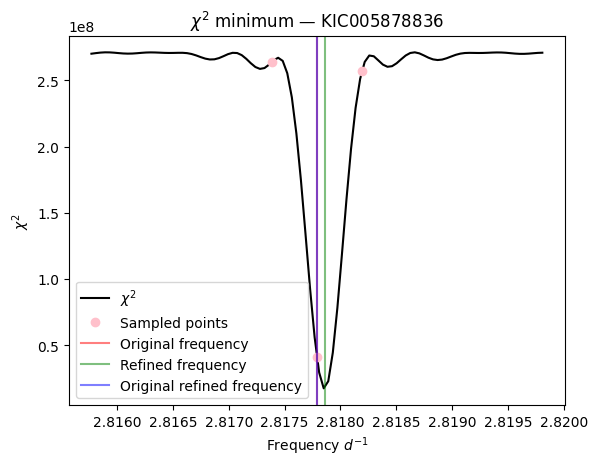

(2.8178584142234477,
 array([ 9.96217751e-01,  5.50554101e-03,  1.69374718e-03,  9.51008115e-03,
        -3.25725084e-02, -2.94167389e-04,  3.08640330e-04,  4.49365044e-03,
         2.25647347e-03, -2.03736112e-04, -6.10335965e-04, -1.33941026e-03,
         1.61914769e-03,  1.97176153e-04, -2.01422716e-05, -2.38889150e-04,
        -2.88384538e-04,  1.38627496e-05,  1.90988480e-05, -5.96580173e-05,
         1.86503012e-05,  4.45154686e-05,  1.18167634e-05,  3.34930638e-05,
        -1.41613263e-05,  2.81534777e-05,  3.95856089e-05,  1.33027958e-05,
         7.50138516e-05, -2.34326579e-05, -1.59337502e-04, -2.06764198e-04,
         4.83781997e-04,  1.14598075e-03,  1.44109504e-03,  1.70152894e-04,
        -1.02149839e-05,  5.62798302e-05, -3.37729441e-04, -9.41579585e-06,
         9.13663782e-05, -7.11396069e-05,  9.88488852e-05, -2.14403972e-05,
        -1.17806222e-04, -3.06313643e-05, -3.95776435e-05,  1.64073244e-05,
         4.62727607e-05,  8.10266990e-06, -3.59848032e-05, -3.36404

In [22]:
nana.fit_fourier_series_to_mode(27295, 32, True)

rank: 18, index: 344, star_id: KIC005962716, freq: 0.5541
starting to download data for KIC005962716
KIC005962716 is long cadence
nana.get_kepler_data() took 0.5541582107543945 seconds


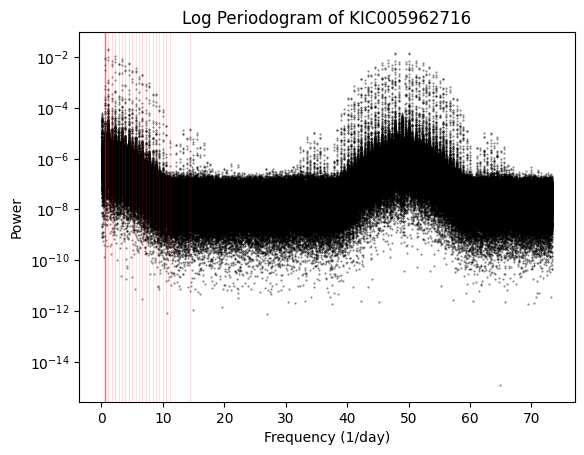

feature length: 65, M: 32


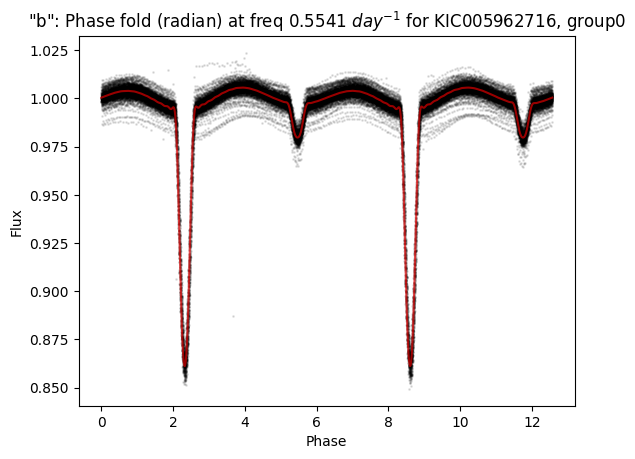

rank: 18, index: 878, star_id: KIC005610698, freq: 0.7260
starting to download data for KIC005610698
KIC005610698 is long cadence
nana.get_kepler_data() took 0.4842560291290283 seconds


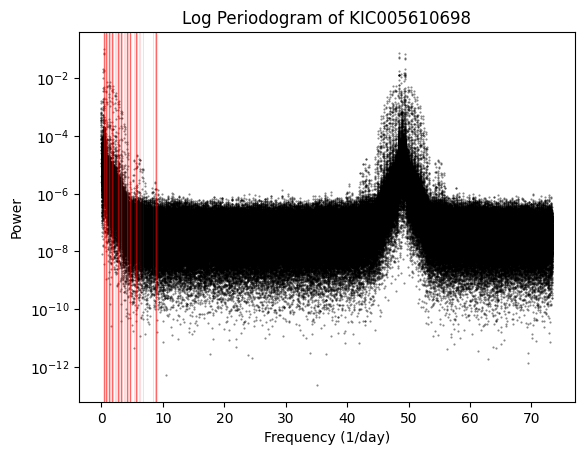

feature length: 65, M: 32


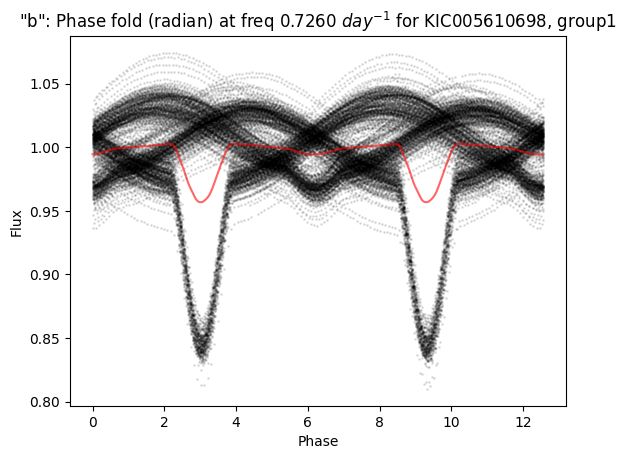

rank: 18, index: 693, star_id: KIC011234677, freq: 0.6300
starting to download data for KIC011234677
KIC011234677 is long cadence
nana.get_kepler_data() took 0.4790372848510742 seconds


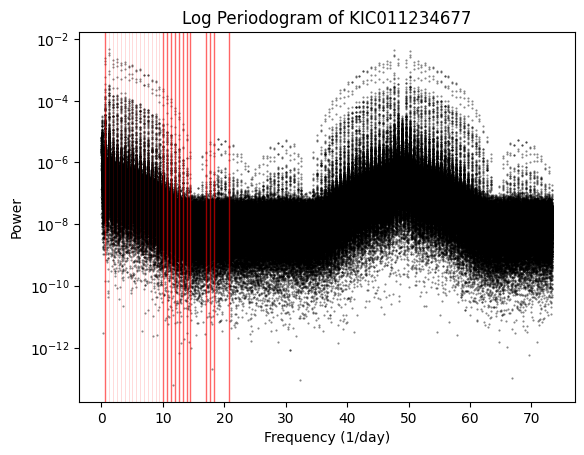

feature length: 65, M: 32


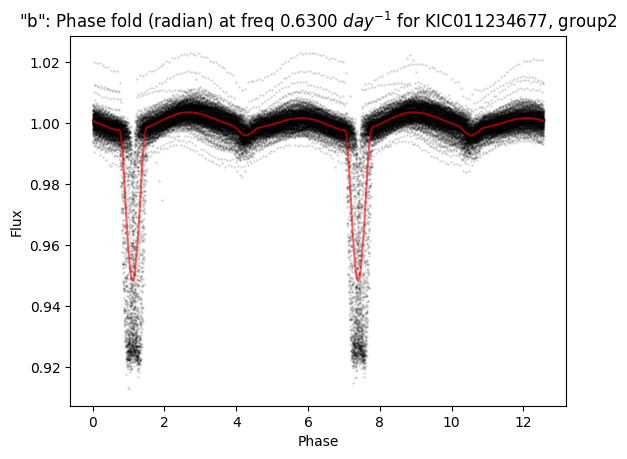

rank: 18, index: 1415, star_id: KIC003448245, freq: 1.9475
starting to download data for KIC003448245
KIC003448245 is long cadence
nana.get_kepler_data() took 0.5298709869384766 seconds


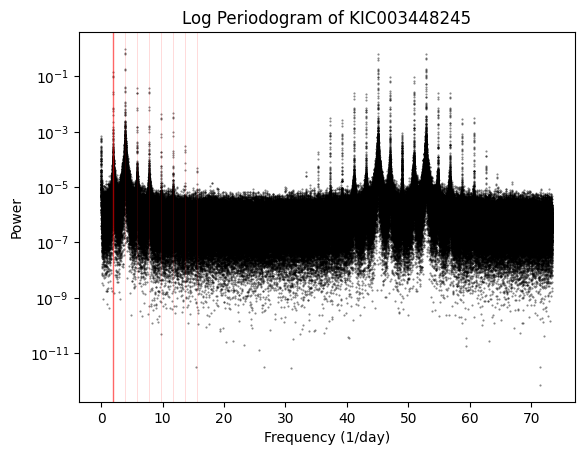

feature length: 65, M: 32


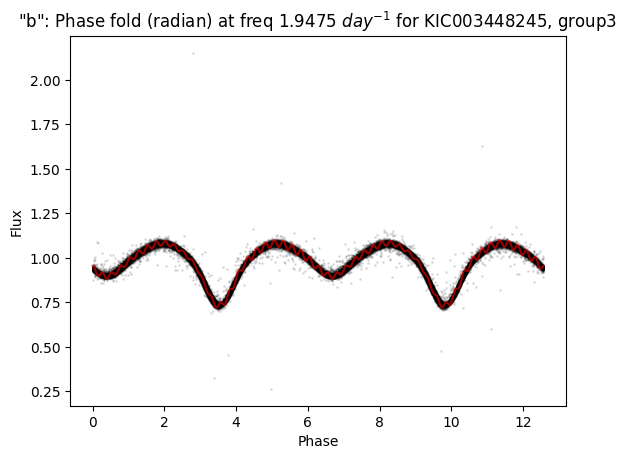

rank: 18, index: 264, star_id: KIC007977261, freq: 1.0801
starting to download data for KIC007977261
KIC007977261 is long cadence
nana.get_kepler_data() took 0.5148489475250244 seconds


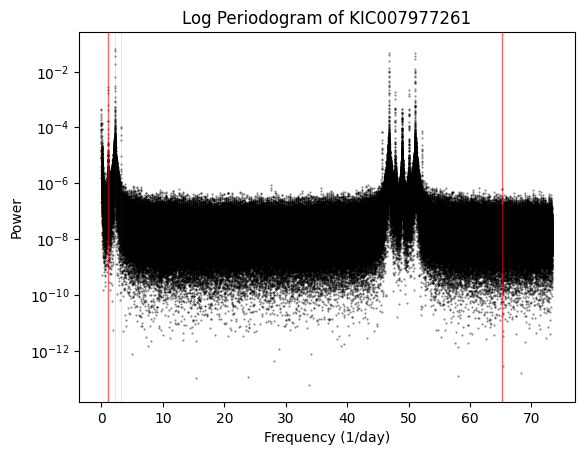

feature length: 65, M: 32


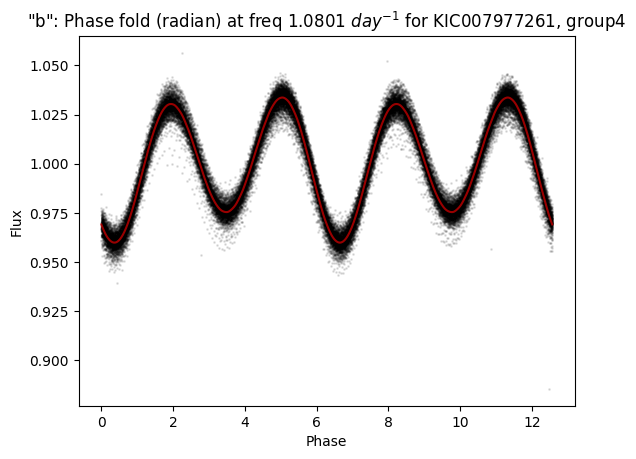

rank: 18, index: 913, star_id: KIC011671429, freq: 0.0356
starting to download data for KIC011671429
KIC011671429 is long cadence
nana.get_kepler_data() took 0.5281352996826172 seconds


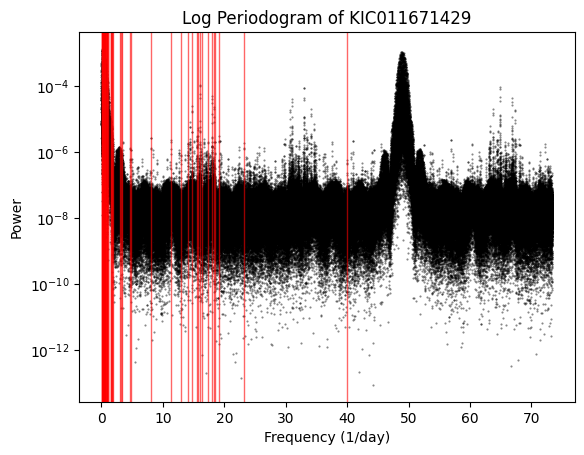

feature length: 65, M: 32


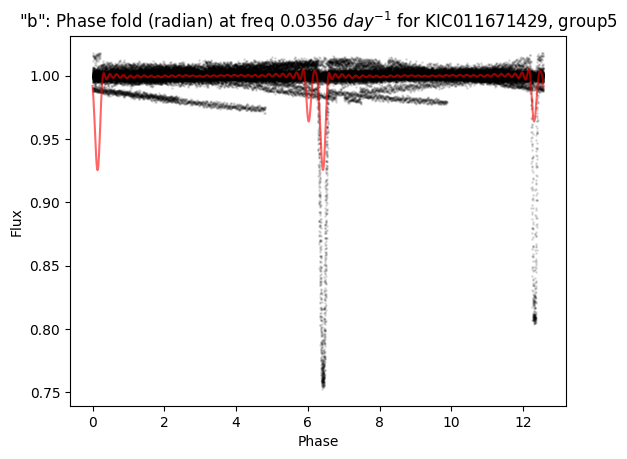

rank: 18, index: 210, star_id: KIC006863840, freq: 2.8551
starting to download data for KIC006863840
KIC006863840 is long cadence
nana.get_kepler_data() took 0.4867250919342041 seconds


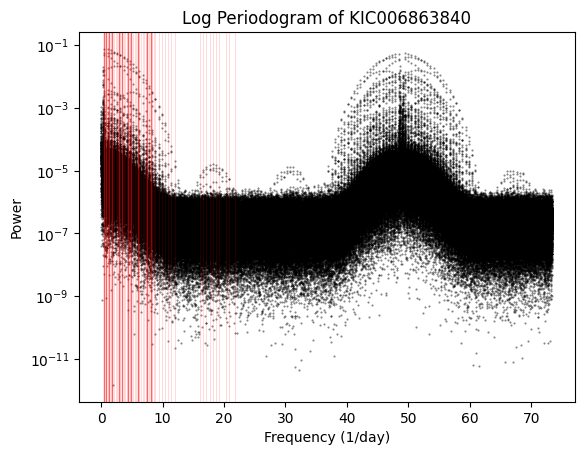

feature length: 65, M: 32


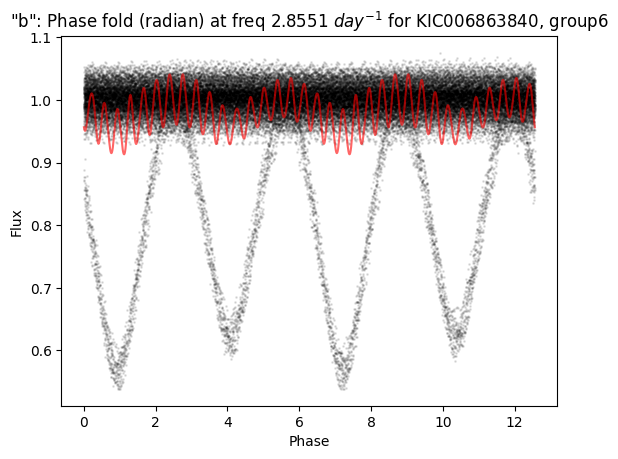

rank: 18, index: 625, star_id: KIC010753734, freq: 0.2576
starting to download data for KIC010753734
KIC010753734 is long cadence
nana.get_kepler_data() took 0.42699694633483887 seconds


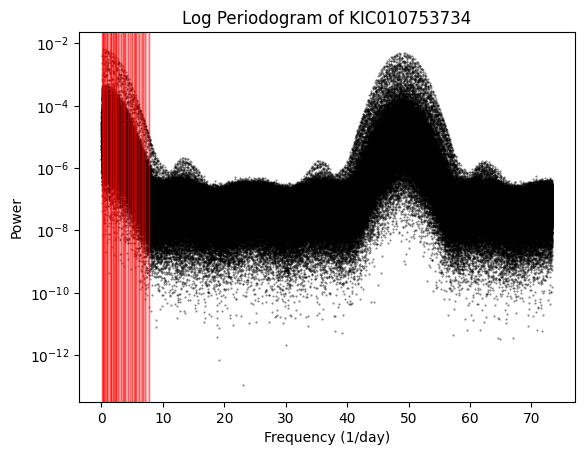

feature length: 65, M: 32


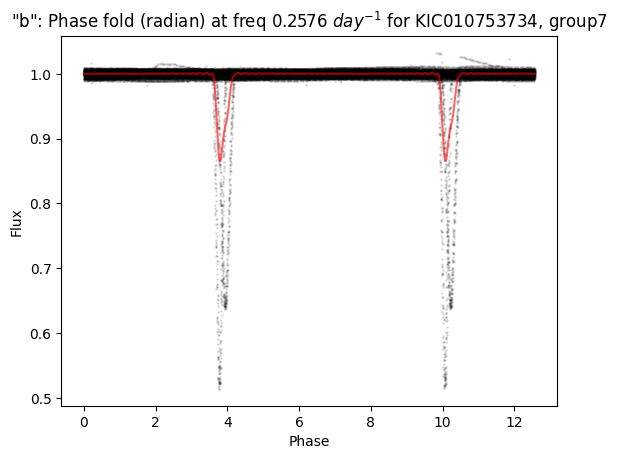

rank: 18, index: 1015, star_id: KIC008621353, freq: 1.4985
starting to download data for KIC008621353
KIC008621353 is long cadence
nana.get_kepler_data() took 0.2488851547241211 seconds


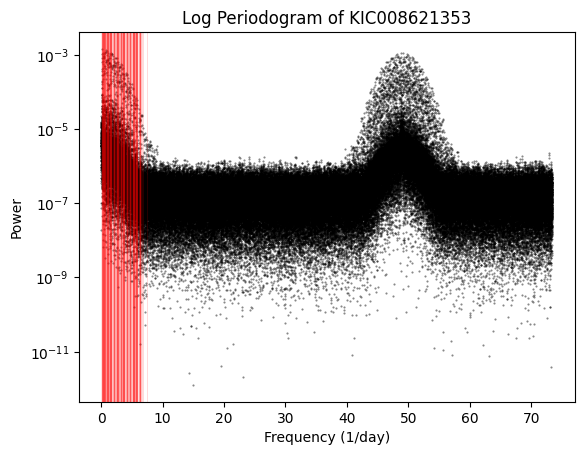

feature length: 65, M: 32


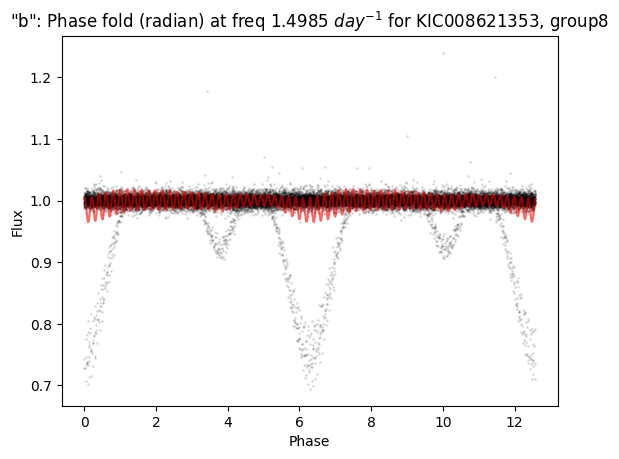

In [23]:
K, r = 9, 82

kmeans = KMeans(n_clusters=K, init='k-means++', random_state=r)
kmeans.fit(log_squared_feats)
for group in range(K):
    phase_folding_by_rank(group, K, r, kmeans, 18)